In [1]:
# Лабораторна робота №4
## Візуалізація гармоніки з шумом

Реалізація інтерактивної програми для побудови гармоніки з шумом, з можливістю змінювати параметри сигналу та фільтра.

SyntaxError: invalid syntax (1249710842.py, line 4)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

In [8]:
def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_covariance, t, noise=None):
    clean = amplitude * np.sin(frequency * t + phase)
    
    if noise is None:
        noise = np.random.normal(noise_mean, noise_covariance, len(t))
    
    noisy = clean + noise
    return clean, noisy, noise


def apply_filter(signal, cutoff):
    b, a = butter(N=3, Wn=cutoff)
    return filtfilt(b, a, signal)

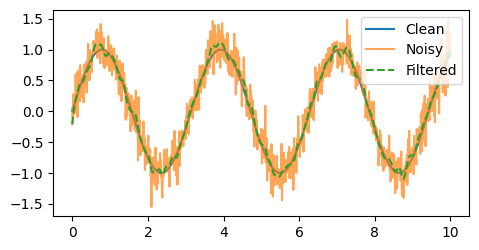

In [9]:
t = np.linspace(0, 10, 1000)

# початкові значення
amp0 = 1
freq0 = 2
phase0 = 0
noise_mean0 = 0
noise_cov0 = 0.2
cutoff0 = 0.1

# початковий шум
noise = np.random.normal(noise_mean0, noise_cov0, len(t))

fig, ax = plt.subplots()
plt.subplots_adjust(left=0.25, bottom=0.45)

# початкові дані
clean, noisy, _ = harmonic_with_noise(amp0, freq0, phase0, noise_mean0, noise_cov0, t, noise)
filtered = apply_filter(noisy, cutoff0)

# графіки
l_clean, = plt.plot(t, clean, label="Clean")
l_noisy, = plt.plot(t, noisy, label="Noisy", alpha=0.7)
l_filtered, = plt.plot(t, filtered, label="Filtered", linestyle='--')

plt.legend()

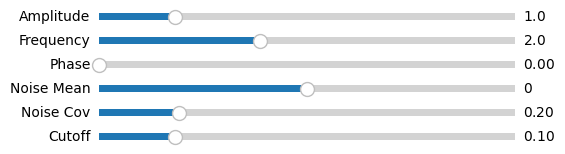

In [10]:
ax_amp = plt.axes([0.25, 0.35, 0.65, 0.03])
ax_freq = plt.axes([0.25, 0.30, 0.65, 0.03])
ax_phase = plt.axes([0.25, 0.25, 0.65, 0.03])
ax_noise_mean = plt.axes([0.25, 0.20, 0.65, 0.03])
ax_noise_cov = plt.axes([0.25, 0.15, 0.65, 0.03])
ax_cutoff = plt.axes([0.25, 0.10, 0.65, 0.03])

s_amp = Slider(ax_amp, 'Amplitude', 0.1, 5.0, valinit=amp0)
s_freq = Slider(ax_freq, 'Frequency', 0.1, 5.0, valinit=freq0)
s_phase = Slider(ax_phase, 'Phase', 0, 3.14, valinit=phase0)
s_noise_mean = Slider(ax_noise_mean, 'Noise Mean', -1, 1, valinit=noise_mean0)
s_noise_cov = Slider(ax_noise_cov, 'Noise Cov', 0.01, 1, valinit=noise_cov0)
s_cutoff = Slider(ax_cutoff, 'Cutoff', 0.01, 0.5, valinit=cutoff0)

In [ ]:
def update(val):
    global noise
    
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    
    new_mean = s_noise_mean.val
    new_cov = s_noise_cov.val
    cutoff = s_cutoff.val

    # шум змінюється тільки якщо змінюються його параметри
    if new_mean != noise_mean0 or new_cov != noise_cov0:
        noise = np.random.normal(new_mean, new_cov, len(t))

    clean, noisy, _ = harmonic_with_noise(amp, freq, phase, new_mean, new_cov, t, noise)
    filtered = apply_filter(noisy, cutoff)

    l_clean.set_ydata(clean)
    l_noisy.set_ydata(noisy)
    l_filtered.set_ydata(filtered)

    fig.canvas.draw_idle()


for s in [s_amp, s_freq, s_phase, s_noise_mean, s_noise_cov, s_cutoff]:
    s.on_changed(update)

In [ ]:
rax = plt.axes([0.02, 0.5, 0.15, 0.15])
check = CheckButtons(rax, ['Show Noise'], [True])

def toggle(label):
    l_noisy.set_visible(not l_noisy.get_visible())
    fig.canvas.draw_idle()

check.on_clicked(toggle)

In [ ]:
resetax = plt.axes([0.8, 0.02, 0.1, 0.04])
button = Button(resetax, 'Reset')

def reset(event):
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_noise_mean.reset()
    s_noise_cov.reset()
    s_cutoff.reset()

button.on_clicked(reset)

In [ ]:
## Інструкція користувача

- Слайдери Amplitude, Frequency, Phase змінюють гармоніку
- Noise Mean та Noise Cov змінюють шум
- Cutoff керує фільтром
- Show Noise — вмикає/вимикає шум
- Reset — повертає початкові значення